In [1]:

#  STEP 1: Load Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils import resample


In [2]:
#   Upload Dataset
file_path = "/content/CSMS.xlsx"
df = pd.read_excel(file_path)


In [3]:
# Drop 'Understanding' column
if 'Understanding' in df.columns:
    df = df.drop(columns=['Understanding'])
    print("✅ 'Understanding' column removed.")


✅ 'Understanding' column removed.


In [4]:
#  Clean column names
df.columns = df.columns.str.strip()

In [5]:
#   Remove rows having >=4 zeros
input_cols = [
    "Course overview", "Reading file", "Abstract materiale", "Concrete material",
    "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
    "playing", "paused", "unstarted", "buffering"
]

def should_delete(row):
    zero_count = (row[input_cols] == 0).sum()
    return zero_count >= 4

df_cleaned = df[~df.apply(should_delete, axis=1)].reset_index(drop=True)


In [6]:
#   Split labelled and unlabelled
labelled_data = df_cleaned[df_cleaned["Processing"].notnull()].copy()
unlabelled_data = df_cleaned[df_cleaned["Processing"].isnull()].copy()

X_labelled = labelled_data[input_cols]
y_labelled = labelled_data[["Processing", "Perception", "Input"]]
#   Encode targets
encoders = {}
y_encoded = pd.DataFrame()

for col in y_labelled.columns:
    le = LabelEncoder()
    y_encoded[col] = le.fit_transform(y_labelled[col])
    encoders[col] = le
    #   Scale input
scaler = StandardScaler()
X_labelled_scaled = scaler.fit_transform(X_labelled)
#  Balance dataset (upsample minority classes)
df_balanced = pd.DataFrame(X_labelled_scaled, columns=input_cols)
df_balanced['Processing'] = y_encoded["Processing"]

max_size = df_balanced['Processing'].value_counts().max()

lst = [df_balanced]
for class_index, group in df_balanced.groupby('Processing'):
    lst.append(group.sample(max_size - len(group), replace=True, random_state=42))

df_balanced = pd.concat(lst).reset_index(drop=True)

X_balanced = df_balanced[input_cols]
y_balanced = df_balanced['Processing']
#   Split Balanced Data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)
#   Define 10 Models
models = {
    "RandomForest": RandomForestClassifier(),
    "XGBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

results = {}
#   Train and Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "Confusion Matrix": cm
    }
#  STEP 12: Show results
results_df = pd.DataFrame(results).T
print(results_df)

                    Accuracy  F1 Score      Confusion Matrix
RandomForest        0.611111  0.603459   [[22, 8], [13, 11]]
XGBoost             0.592593  0.590307  [[20, 10], [12, 12]]
AdaBoost            0.462963  0.463892  [[15, 15], [14, 10]]
Bagging             0.555556  0.544012    [[21, 9], [15, 9]]
ExtraTrees          0.592593  0.593716  [[18, 12], [10, 14]]
LogisticRegression  0.518519  0.515873   [[13, 17], [9, 15]]
NaiveBayes          0.462963  0.445917    [[9, 21], [8, 16]]
SVM                 0.555556  0.555556   [[15, 15], [9, 15]]
KNN                 0.518519  0.518519  [[17, 13], [13, 11]]
DecisionTree        0.574074  0.573034  [[19, 11], [12, 12]]


In [7]:
#   Split labelled and unlabelled
labelled_data = df_cleaned[df_cleaned["Perception"].notnull()].copy()
unlabelled_data = df_cleaned[df_cleaned["Perception"].isnull()].copy()

X_labelled = labelled_data[input_cols]
y_labelled = labelled_data[["Processing", "Perception", "Input"]]
#   Encode targets
encoders = {}
y_encoded = pd.DataFrame()

for col in y_labelled.columns:
    le = LabelEncoder()
    y_encoded[col] = le.fit_transform(y_labelled[col])
    encoders[col] = le
    #   Scale input
scaler = StandardScaler()
X_labelled_scaled = scaler.fit_transform(X_labelled)
#  Balance dataset (upsample minority classes)
df_balanced = pd.DataFrame(X_labelled_scaled, columns=input_cols)
df_balanced['Perception'] = y_encoded["Perception"]

max_size = df_balanced['Perception'].value_counts().max()

lst = [df_balanced]
for class_index, group in df_balanced.groupby('Perception'):
    lst.append(group.sample(max_size - len(group), replace=True, random_state=42))

df_balanced = pd.concat(lst).reset_index(drop=True)

X_balanced = df_balanced[input_cols]
y_balanced = df_balanced['Perception']
#   Split Balanced Data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)
#   Define 10 Models
models = {
    "RandomForest": RandomForestClassifier(),
    "XGBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

results = {}
#   Train and Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "Confusion Matrix": cm
    }
#  STEP 12: Show results
results_df = pd.DataFrame(results).T
print(results_df)

                    Accuracy  F1 Score      Confusion Matrix
RandomForest             0.6  0.599204  [[15, 12], [10, 18]]
XGBoost             0.472727   0.47168  [[14, 13], [16, 12]]
AdaBoost            0.618182  0.617929  [[16, 11], [10, 18]]
Bagging             0.581818  0.581818  [[16, 11], [12, 16]]
ExtraTrees          0.636364  0.633939   [[15, 12], [8, 20]]
LogisticRegression  0.490909  0.490909  [[13, 14], [14, 14]]
NaiveBayes          0.472727  0.470624  [[11, 16], [13, 15]]
SVM                 0.618182  0.616659   [[15, 12], [9, 19]]
KNN                 0.618182  0.617423   [[18, 9], [12, 16]]
DecisionTree        0.727273  0.727092    [[19, 8], [7, 21]]


In [8]:

#   Split labelled and unlabelled
labelled_data = df_cleaned[df_cleaned["Input"].notnull()].copy()
unlabelled_data = df_cleaned[df_cleaned["Input"].isnull()].copy()

X_labelled = labelled_data[input_cols]
y_labelled = labelled_data[["Processing", "Perception", "Input"]]
#   Encode targets
encoders = {}
y_encoded = pd.DataFrame()

for col in y_labelled.columns:
    le = LabelEncoder()
    y_encoded[col] = le.fit_transform(y_labelled[col])
    encoders[col] = le
    #   Scale input
scaler = StandardScaler()
X_labelled_scaled = scaler.fit_transform(X_labelled)
#  Balance dataset (upsample minority classes)
df_balanced = pd.DataFrame(X_labelled_scaled, columns=input_cols)
df_balanced['Input'] = y_encoded["Input"]

max_size = df_balanced['Input'].value_counts().max()

lst = [df_balanced]
for class_index, group in df_balanced.groupby('Input'):
    lst.append(group.sample(max_size - len(group), replace=True, random_state=42))

df_balanced = pd.concat(lst).reset_index(drop=True)

X_balanced = df_balanced[input_cols]
y_balanced = df_balanced['Input']
#   Split Balanced Data
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)
#   Define 10 Models
models = {
    "RandomForest": RandomForestClassifier(),
    "XGBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging": BaggingClassifier(),
    "ExtraTrees": ExtraTreesClassifier(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier()
}

results = {}
#   Train and Evaluate Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1 Score": f1,
        "Confusion Matrix": cm
    }
#  STEP 12: Show results
results_df = pd.DataFrame(results).T
print(results_df)

                    Accuracy  F1 Score      Confusion Matrix
RandomForest        0.964706  0.964765    [[43, 3], [0, 39]]
XGBoost             0.905882  0.905778    [[38, 8], [0, 39]]
AdaBoost            0.682353  0.682618  [[32, 14], [13, 26]]
Bagging             0.882353  0.881864   [[36, 10], [0, 39]]
ExtraTrees               1.0       1.0    [[46, 0], [0, 39]]
LogisticRegression  0.541176  0.541176  [[23, 23], [16, 23]]
NaiveBayes          0.517647  0.499272  [[32, 14], [27, 12]]
SVM                 0.741176  0.737642   [[28, 18], [4, 35]]
KNN                 0.705882  0.704087   [[28, 18], [7, 32]]
DecisionTree        0.870588  0.869798   [[35, 11], [0, 39]]


In [9]:
#   Label Unlabeled Data using Semi-supervised learning
from sklearn.semi_supervised import SelfTrainingClassifier

#  Prepare Unlabeled data inputs
X_unlabelled = unlabelled_data[input_cols]
X_unlabelled_scaled = scaler.transform(X_unlabelled)

#  Combine labelled + unlabelled
X_combined = np.vstack((X_labelled_scaled, X_unlabelled_scaled))

# Prepare y_combined
y_combined = np.concatenate((y_encoded["Processing"], [-1]*len(X_unlabelled_scaled)))

#  Use best model → RandomForest as base
base_model = RandomForestClassifier()

#  Create Self Training Model
self_training_model = SelfTrainingClassifier(base_model)
self_training_model.fit(X_combined, y_combined)

#  Predict pseudo-labels for unlabelled
pseudo_labels = self_training_model.predict(X_unlabelled_scaled)

#  Decode labels to original (reverse transform)
pseudo_labels_decoded = encoders["Processing"].inverse_transform(pseudo_labels)

#  Add predicted labels to unlabelled_data
unlabelled_data["Predicted Processing"] = pseudo_labels_decoded

#  Show final labelled unlabelled data
print(unlabelled_data[["id", "Predicted Processing"]].head(20))


            id Predicted Processing
249  0140HJ399                  REF
250  0150FK726                  ACT
251  0150LJ813                  REF
252  0155JC081                  REF
253  0155CZ525                  ACT
254  0156RY050                  REF
255  0156RF202                  REF
256  0160RK011                  ACT
257  0160VV733                  REF
258  0161NU077                  REF
259  0161BL377                  ACT
260  0161NW602                  ACT
261  0162RO310                  ACT
262  0164BU032                  REF
263  0164AL184                  REF
264  0164FI314                  ACT
265  0165ER301                  ACT
266  0165CD991                  ACT
267  0166MH317                  ACT
268  0167GE103                  ACT


In [10]:
unlabelled_data.to_csv("Unlabelled_with_Predicted_LabelsProcessing.csv", index=False)
print("Saved as CSV.")


Saved as CSV.


In [11]:
#  Label Unlabeled Data using Semi-supervised learning
from sklearn.semi_supervised import SelfTrainingClassifier

#  Prepare Unlabeled data inputs
X_unlabelled = unlabelled_data[input_cols]
X_unlabelled_scaled = scaler.transform(X_unlabelled)

#  Combine labelled + unlabelled
X_combined = np.vstack((X_labelled_scaled, X_unlabelled_scaled))

# Prepare y_combined
y_combined = np.concatenate((y_encoded["Perception"], [-1]*len(X_unlabelled_scaled)))

#  Use best model → RandomForest as base
base_model = RandomForestClassifier()

#  Create Self Training Model
self_training_model = SelfTrainingClassifier(base_model)
self_training_model.fit(X_combined, y_combined)

#  Predict pseudo-labels for unlabelled
pseudo_labels = self_training_model.predict(X_unlabelled_scaled)

#  Decode labels to original (reverse transform)
pseudo_labels_decoded = encoders["Perception"].inverse_transform(pseudo_labels)

#  Add predicted labels to unlabelled_data
unlabelled_data["Predicted Perception"] = pseudo_labels_decoded

#  Show final labelled unlabelled data
print(unlabelled_data[["id", "Predicted Perception"]].head(20))
unlabelled_data.to_csv("Unlabelled_with_Predicted_LabelsPerception.csv", index=False)
print("Saved as CSV.")



            id Predicted Perception
249  0140HJ399                  SEN
250  0150FK726                  SEN
251  0150LJ813                  SEN
252  0155JC081                  SEN
253  0155CZ525                  SEN
254  0156RY050                  SEN
255  0156RF202                  SEN
256  0160RK011                  SEN
257  0160VV733                  SEN
258  0161NU077                  SEN
259  0161BL377                  INT
260  0161NW602                  SEN
261  0162RO310                  SEN
262  0164BU032                  INT
263  0164AL184                  INT
264  0164FI314                  INT
265  0165ER301                  SEN
266  0165CD991                  SEN
267  0166MH317                  SEN
268  0167GE103                  SEN
Saved as CSV.


In [12]:
#   Label Unlabeled Data using Semi-supervised learning
from sklearn.semi_supervised import SelfTrainingClassifier

#  Prepare Unlabeled data inputs
X_unlabelled = unlabelled_data[input_cols]
X_unlabelled_scaled = scaler.transform(X_unlabelled)

#  Combine labelled + unlabelled
X_combined = np.vstack((X_labelled_scaled, X_unlabelled_scaled))

# Prepare y_combined
y_combined = np.concatenate((y_encoded["Input"], [-1]*len(X_unlabelled_scaled)))

#  Use best model → RandomForest as base
base_model = RandomForestClassifier()

#  Create Self Training Model
self_training_model = SelfTrainingClassifier(base_model)
self_training_model.fit(X_combined, y_combined)

#  Predict pseudo-labels for unlabelled
pseudo_labels = self_training_model.predict(X_unlabelled_scaled)

#  Decode labels to original (reverse transform)
pseudo_labels_decoded = encoders["Input"].inverse_transform(pseudo_labels)

#  Add predicted labels to unlabelled_data
unlabelled_data["Predicted Input"] = pseudo_labels_decoded

#  Show final labelled unlabelled data
print(unlabelled_data[["id", "Predicted Input"]].head(20))
unlabelled_data.to_csv("Unlabelled_with_Predicted_LabelsInput.csv", index=False)
print("Saved as CSV.")


            id Predicted Input
249  0140HJ399             VIS
250  0150FK726             VIS
251  0150LJ813             VIS
252  0155JC081             VIS
253  0155CZ525             VIS
254  0156RY050             VIS
255  0156RF202             VIS
256  0160RK011             VIS
257  0160VV733             VIS
258  0161NU077             VIS
259  0161BL377             VIS
260  0161NW602             VIS
261  0162RO310             VIS
262  0164BU032             VIS
263  0164AL184             VIS
264  0164FI314             VIS
265  0165ER301             VIS
266  0165CD991             VIS
267  0166MH317             VIS
268  0167GE103             VIS
Saved as CSV.


In [14]:
# INSTALL LIBRARY
!pip install imbalanced-learn

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

# DEFINE FILES AND TARGET COLUMN NAMES
files_targets = {
    "Unlabelled_with_Predicted_LabelsProcessing.csv": "Predicted Processing",
    "Unlabelled_with_Predicted_LabelsPerception.csv": "Predicted Perception",
    "Unlabelled_with_Predicted_LabelsInput.csv": "Predicted Input"
}

# INPUT COLUMNS
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# TO STORE ALL RESULTS
final_results = {}

# LOOP THROUGH EACH FILE AND TRAIN MODELS
for file, target_column in files_targets.items():
    print("\n=============================")
    print(" FILE:", file, "| TARGET:", target_column)
    print("=============================")

    # Load data
    df = pd.read_csv("/content/" + file)

    # Prepare input and target
    X = df[input_cols]
    y = df[target_column]

    # Encode target
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Scale inputs
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Check class counts
    class_counts = Counter(y_encoded)
    min_class_size = min(class_counts.values())

    # Apply SMOTE only if smallest class has > 5 samples
    if min_class_size > 5:
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_scaled, y_encoded)
        print("✅ SMOTE Applied → Class Distribution:", np.bincount(y_balanced))
    else:
        X_balanced, y_balanced = X_scaled, y_encoded
        print("⚠️ SMOTE Skipped → Not enough samples in smallest class:", min_class_size)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

    # Define Models
    models = {
        "RandomForest": RandomForestClassifier(),
        "XGBoost": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Bagging": BaggingClassifier(),
        "ExtraTrees": ExtraTreesClassifier(),
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "NaiveBayes": GaussianNB(),
        "SVM": SVC(),
        "KNN": KNeighborsClassifier(),
        "DecisionTree": DecisionTreeClassifier()
    }

    results = {}

    # Train + Evaluate Models
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        cm = confusion_matrix(y_test, y_pred)

        results[name] = {
            "Accuracy": acc,
            "F1 Score": f1,
            "Confusion Matrix": cm
        }

    # Save Result
    results_df = pd.DataFrame(results).T
    final_results[target_column] = results_df

# FINAL SEPARATE PRINTING
for target, result_df in final_results.items():
    print("\n===============================")
    print("📌 FINAL RESULT →", target.upper())
    print("===============================")
    print(result_df)



 FILE: Unlabelled_with_Predicted_LabelsProcessing.csv | TARGET: Predicted Processing
✅ SMOTE Applied → Class Distribution: [169 169]

 FILE: Unlabelled_with_Predicted_LabelsPerception.csv | TARGET: Predicted Perception
✅ SMOTE Applied → Class Distribution: [250 250]

 FILE: Unlabelled_with_Predicted_LabelsInput.csv | TARGET: Predicted Input
⚠️ SMOTE Skipped → Not enough samples in smallest class: 4


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use th


📌 FINAL RESULT → PREDICTED PROCESSING
                    Accuracy  F1 Score      Confusion Matrix
RandomForest        0.926471   0.92655    [[32, 5], [0, 31]]
XGBoost             0.867647   0.86779    [[30, 7], [2, 29]]
AdaBoost            0.882353  0.882353    [[33, 4], [4, 27]]
Bagging             0.911765  0.911917    [[32, 5], [1, 30]]
ExtraTrees          0.911765  0.911765    [[31, 6], [0, 31]]
LogisticRegression  0.617647  0.617647  [[24, 13], [13, 18]]
NaiveBayes          0.661765  0.642167   [[32, 5], [18, 13]]
SVM                 0.779412  0.776774   [[24, 13], [2, 29]]
KNN                 0.676471   0.67535   [[22, 15], [7, 24]]
DecisionTree        0.867647   0.86779    [[30, 7], [2, 29]]

📌 FINAL RESULT → PREDICTED PERCEPTION
                   Accuracy  F1 Score      Confusion Matrix
RandomForest           0.93  0.929463    [[54, 1], [6, 39]]
XGBoost                0.94  0.939657    [[54, 1], [5, 40]]
AdaBoost               0.89  0.888652    [[53, 2], [9, 36]]
Bagging    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use th

In [15]:
#  Install required library (run only once in Colab)
!pip install imbalanced-learn

#  Import libraries
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE

#  Define files and target columns
files_targets = {
    "Unlabelled_with_Predicted_LabelsProcessing.csv": "Predicted Processing",
    "Unlabelled_with_Predicted_LabelsPerception.csv": "Predicted Perception",
    "Unlabelled_with_Predicted_LabelsInput.csv": "Predicted Input"
}

#  Define input columns
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

#  To store all results
final_results = {}

#  Loop through each dataset
for file, target_column in files_targets.items():
    print("\n=============================")
    print(" FILE:", file, "| TARGET:", target_column)
    print("=============================")

    # Load dataset
    df = pd.read_csv("/content/" + file)

    # Prepare input (X) and target (y)
    X = df[input_cols]
    y = df[target_column]

    # Encode target
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Scale inputs
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Check smallest class count for SMOTE handling
    counter = Counter(y_encoded)
    min_samples = min(counter.values())

    if min_samples < 2:
        # Too small → skip SMOTE
        print("❗ Too few samples for SMOTE. Using original data.")
        X_balanced, y_balanced = X_scaled, y_encoded
    else:
        # Use SMOTE, adjust k_neighbors if needed
        k_neighbors = min(5, min_samples - 1)
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_balanced, y_balanced = smote.fit_resample(X_scaled, y_encoded)
        print(f" SMOTE Applied with k_neighbors={k_neighbors} → Class Distribution:", np.bincount(y_balanced))

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

    # Define models
    models = {
        "RandomForest": RandomForestClassifier(),
        "XGBoost": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Bagging": BaggingClassifier(),
        "ExtraTrees": ExtraTreesClassifier(),
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "NaiveBayes": GaussianNB(),
        "SVM": SVC(),
        "KNN": KNeighborsClassifier(),
        "DecisionTree": DecisionTreeClassifier()
    }

    results = {}

    # Train and evaluate models
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        cm = confusion_matrix(y_test, y_pred)

        results[name] = {
            "Accuracy": acc,
            "F1 Score": f1,
            "Confusion Matrix": cm
        }

    # Save results for this target
    results_df = pd.DataFrame(results).T
    final_results[target_column] = results_df

#  Final result printing
for target, result_df in final_results.items():
    print("\n===============================")
    print("📌 FINAL RESULT →", target.upper())
    print("===============================")
    print(result_df)



 FILE: Unlabelled_with_Predicted_LabelsProcessing.csv | TARGET: Predicted Processing
 SMOTE Applied with k_neighbors=5 → Class Distribution: [169 169]

 FILE: Unlabelled_with_Predicted_LabelsPerception.csv | TARGET: Predicted Perception
 SMOTE Applied with k_neighbors=5 → Class Distribution: [250 250]

 FILE: Unlabelled_with_Predicted_LabelsInput.csv | TARGET: Predicted Input
 SMOTE Applied with k_neighbors=3 → Class Distribution: [311 311]

📌 FINAL RESULT → PREDICTED PROCESSING
                    Accuracy  F1 Score      Confusion Matrix
RandomForest        0.941176  0.941278    [[33, 4], [0, 31]]
XGBoost             0.867647   0.86779    [[30, 7], [2, 29]]
AdaBoost            0.882353  0.882353    [[33, 4], [4, 27]]
Bagging             0.838235  0.838551    [[30, 7], [4, 27]]
ExtraTrees          0.911765  0.911918    [[33, 4], [2, 29]]
LogisticRegression  0.617647  0.617647  [[24, 13], [13, 18]]
NaiveBayes          0.661765  0.642167   [[32, 5], [18, 13]]
SVM                 0.77941


 FILE: Unlabelled_with_Predicted_LabelsProcessing.csv | TARGET: Predicted Processing
✅ SMOTE Applied (k_neighbors=5) → Class Distribution: [169 169]

📌 Model: RandomForest
Accuracy: 0.9264705882352942
Precision: 0.9303633217993079
Recall: 0.9264705882352942
Specificity: 0.8918918918918919
F1 Score: 0.9266139825377605
Cohen Kappa: 0.8529411764705882
Log Loss: 0.3062772821654891
Train Time (s): 0.7458701133728027
Test Time (s): 0.06281352043151855
Confusion Matrix:
 [[33  4]
 [ 1 30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93        37
           1       0.88      0.97      0.92        31

    accuracy                           0.93        68
   macro avg       0.93      0.93      0.93        68
weighted avg       0.93      0.93      0.93        68



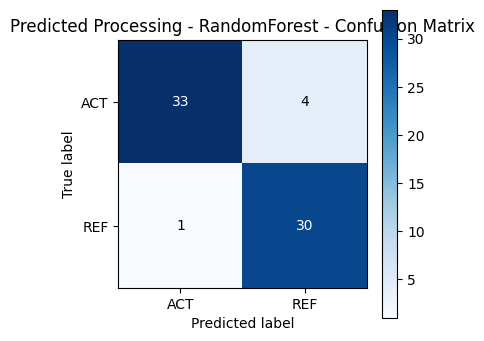

AUC Score: 0.9799476896251089


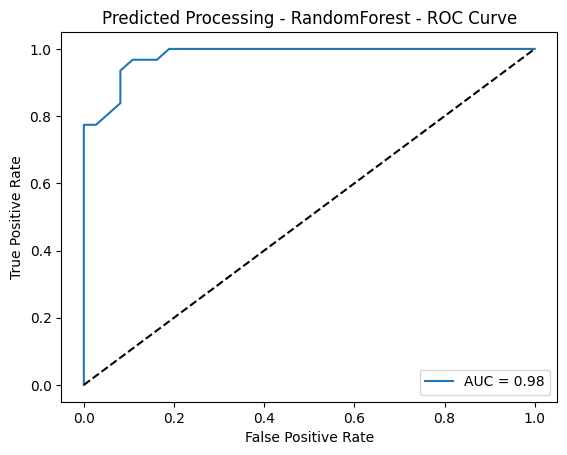


📌 Model: XGBoost
Accuracy: 0.8676470588235294
Precision: 0.8773488562091503
Recall: 0.8676470588235294
Specificity: 0.8108108108108109
F1 Score: 0.8677902049853036
Cohen Kappa: 0.7366609294320138
Log Loss: 0.27861014205965023
Train Time (s): 0.3120903968811035
Test Time (s): 0.016824007034301758
Confusion Matrix:
 [[30  7]
 [ 2 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.81      0.87        37
           1       0.81      0.94      0.87        31

    accuracy                           0.87        68
   macro avg       0.87      0.87      0.87        68
weighted avg       0.88      0.87      0.87        68



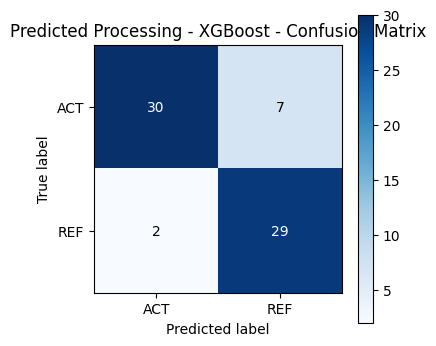

AUC Score: 0.964254577157803


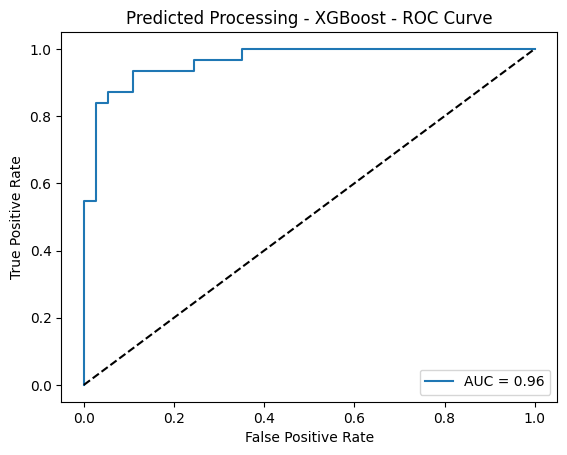


📌 Model: AdaBoost
Accuracy: 0.8823529411764706
Precision: 0.8823529411764706
Recall: 0.8823529411764706
Specificity: 0.8918918918918919
F1 Score: 0.8823529411764706
Cohen Kappa: 0.7628596338273758
Log Loss: 0.568993105712288
Train Time (s): 0.2634875774383545
Test Time (s): 0.04930257797241211
Confusion Matrix:
 [[33  4]
 [ 4 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        37
           1       0.87      0.87      0.87        31

    accuracy                           0.88        68
   macro avg       0.88      0.88      0.88        68
weighted avg       0.88      0.88      0.88        68



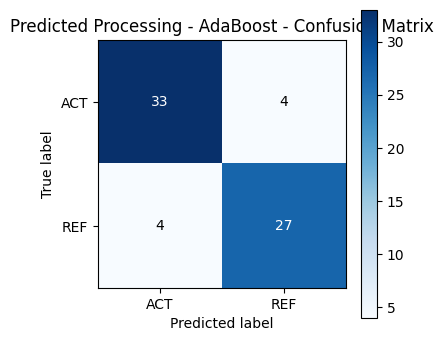

AUC Score: 0.948561464690497


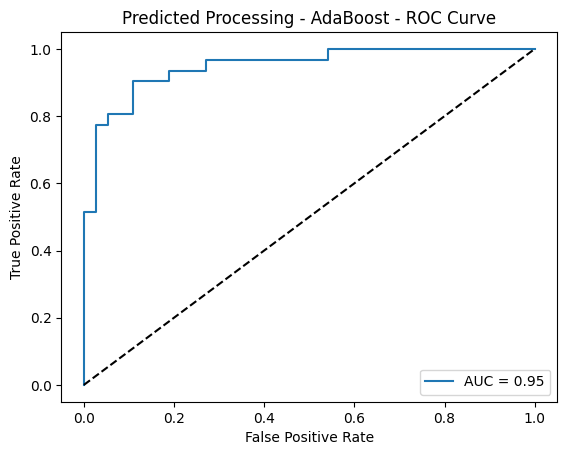


📌 Model: Bagging
Accuracy: 0.9264705882352942
Precision: 0.9270322712418301
Recall: 0.9264705882352942
Specificity: 0.918918918918919
F1 Score: 0.926550528887354
Cohen Kappa: 0.8521739130434782
Log Loss: 0.2839424894818199
Train Time (s): 0.0757591724395752
Test Time (s): 0.0030014514923095703
Confusion Matrix:
 [[34  3]
 [ 2 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93        37
           1       0.91      0.94      0.92        31

    accuracy                           0.93        68
   macro avg       0.93      0.93      0.93        68
weighted avg       0.93      0.93      0.93        68



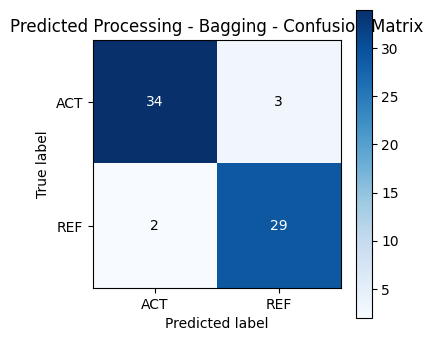

AUC Score: 0.9646904969485616


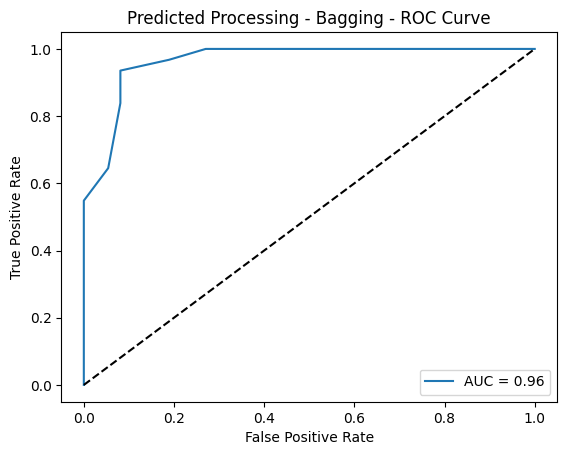


📌 Model: ExtraTrees
Accuracy: 0.9117647058823529
Precision: 0.9136490960020371
Recall: 0.9117647058823529
Specificity: 0.8918918918918919
F1 Score: 0.9119178921568627
Cohen Kappa: 0.8230702515177797
Log Loss: 0.3773097948533013
Train Time (s): 0.27004456520080566
Test Time (s): 0.01212167739868164
Confusion Matrix:
 [[33  4]
 [ 2 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.92        37
           1       0.88      0.94      0.91        31

    accuracy                           0.91        68
   macro avg       0.91      0.91      0.91        68
weighted avg       0.91      0.91      0.91        68



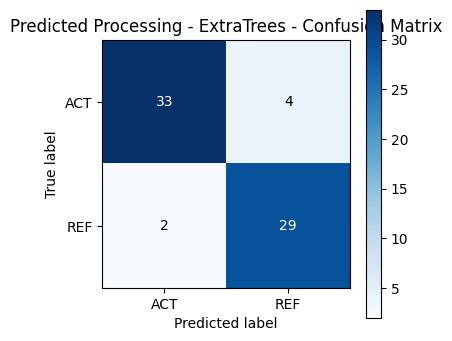

AUC Score: 0.951176983435048


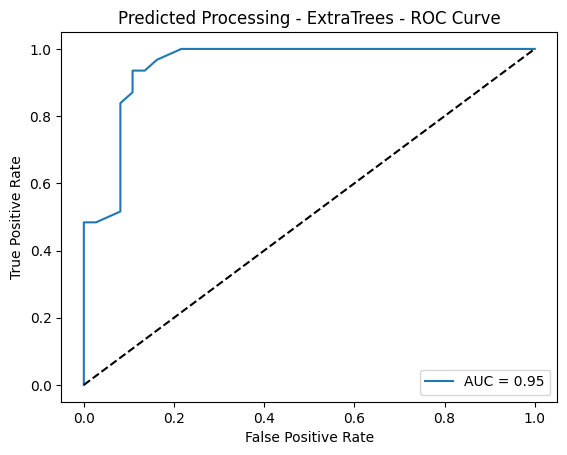


📌 Model: LogisticRegression
Accuracy: 0.6176470588235294
Precision: 0.6176470588235294
Recall: 0.6176470588235294
Specificity: 0.6486486486486487
F1 Score: 0.6176470588235294
Cohen Kappa: 0.2292938099389712
Log Loss: 0.6817320434721298
Train Time (s): 0.034066200256347656
Test Time (s): 0.0002894401550292969
Confusion Matrix:
 [[24 13]
 [13 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.65      0.65        37
           1       0.58      0.58      0.58        31

    accuracy                           0.62        68
   macro avg       0.61      0.61      0.61        68
weighted avg       0.62      0.62      0.62        68



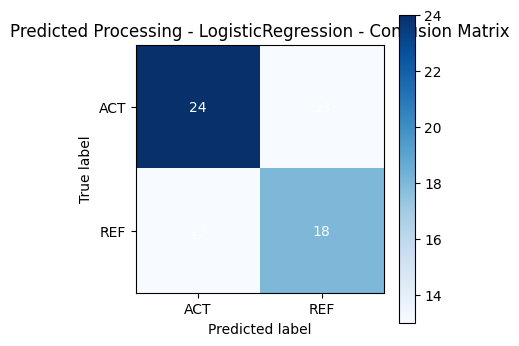

AUC Score: 0.6408020924149956


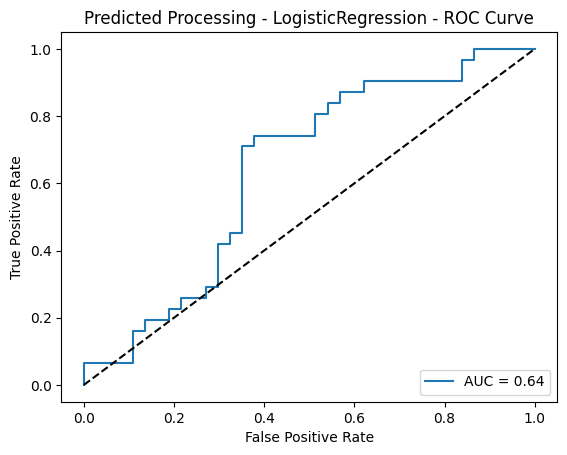


📌 Model: NaiveBayes
Accuracy: 0.6617647058823529
Precision: 0.677483660130719
Recall: 0.6617647058823529
Specificity: 0.8648648648648649
F1 Score: 0.6421672117122711
Cohen Kappa: 0.2942238267148014
Log Loss: 0.8961200929117489
Train Time (s): 0.004991769790649414
Test Time (s): 0.00042247772216796875
Confusion Matrix:
 [[32  5]
 [18 13]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.86      0.74        37
           1       0.72      0.42      0.53        31

    accuracy                           0.66        68
   macro avg       0.68      0.64      0.63        68
weighted avg       0.68      0.66      0.64        68



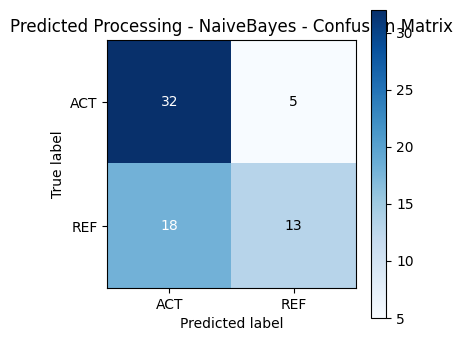

AUC Score: 0.6782911944202267


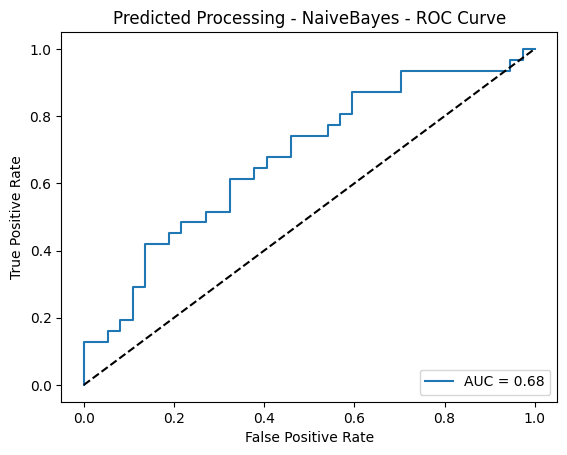


📌 Model: SVM
Accuracy: 0.7794117647058824
Precision: 0.8170383538030597
Recall: 0.7794117647058824
Specificity: 0.6486486486486487
F1 Score: 0.7767737231879053
Cohen Kappa: 0.5677966101694916
Log Loss: 0.5309228121375901
Train Time (s): 0.10203814506530762
Test Time (s): 0.0017855167388916016
Confusion Matrix:
 [[24 13]
 [ 2 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.65      0.76        37
           1       0.69      0.94      0.79        31

    accuracy                           0.78        68
   macro avg       0.81      0.79      0.78        68
weighted avg       0.82      0.78      0.78        68



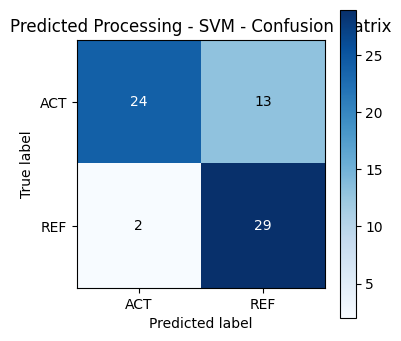

AUC Score: 0.8121185701830862


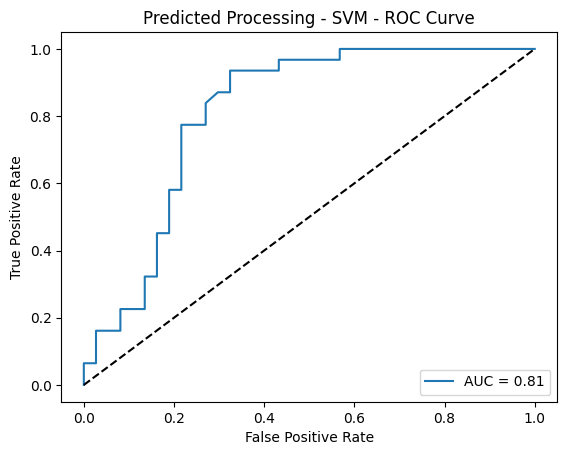


📌 Model: KNN
Accuracy: 0.6764705882352942
Precision: 0.6933218910906538
Recall: 0.6764705882352942
Specificity: 0.5945945945945946
F1 Score: 0.6753501400560225
Cohen Kappa: 0.3612297181895815
Log Loss: 1.0268466295384517
Train Time (s): 0.001542806625366211
Test Time (s): 0.03441119194030762
Confusion Matrix:
 [[22 15]
 [ 7 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.59      0.67        37
           1       0.62      0.77      0.69        31

    accuracy                           0.68        68
   macro avg       0.69      0.68      0.68        68
weighted avg       0.69      0.68      0.68        68



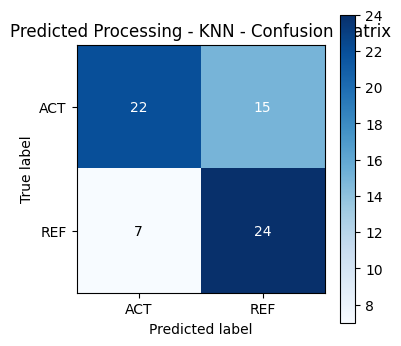

AUC Score: 0.7846556233653007


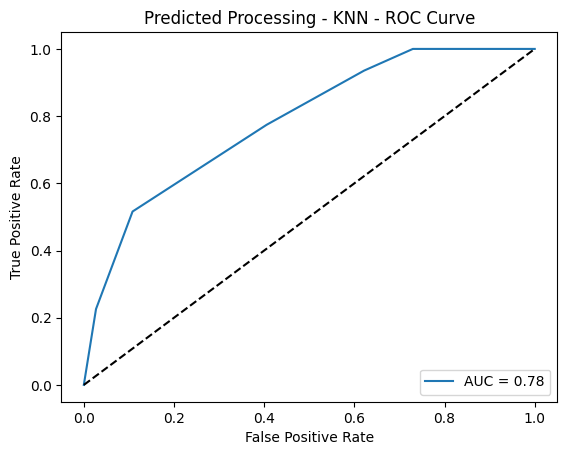


📌 Model: DecisionTree
Accuracy: 0.8676470588235294
Precision: 0.8773488562091503
Recall: 0.8676470588235294
Specificity: 0.8108108108108109
F1 Score: 0.8677902049853036
Cohen Kappa: 0.7366609294320138
Log Loss: 4.770483536794917
Train Time (s): 0.015901803970336914
Test Time (s): 0.006524085998535156
Confusion Matrix:
 [[30  7]
 [ 2 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.81      0.87        37
           1       0.81      0.94      0.87        31

    accuracy                           0.87        68
   macro avg       0.87      0.87      0.87        68
weighted avg       0.88      0.87      0.87        68



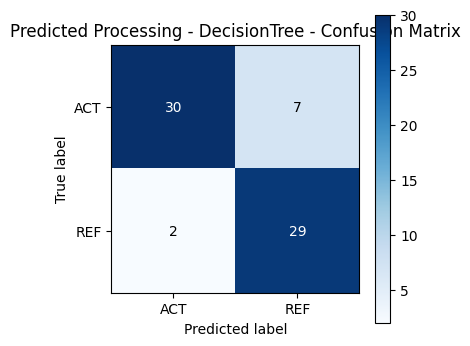

AUC Score: 0.8731473408892763


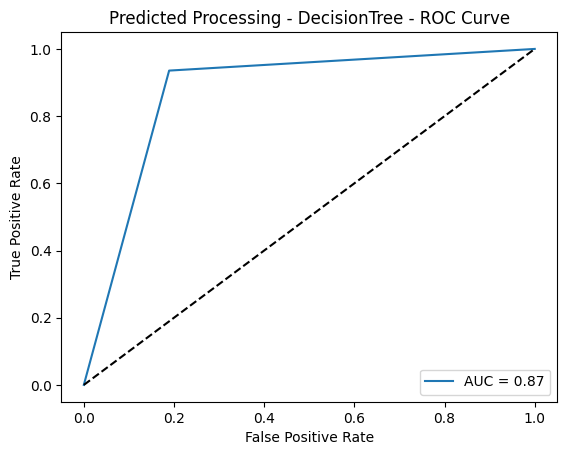


 FILE: Unlabelled_with_Predicted_LabelsPerception.csv | TARGET: Predicted Perception
✅ SMOTE Applied (k_neighbors=5) → Class Distribution: [250 250]

📌 Model: RandomForest
Accuracy: 0.93
Precision: 0.9311576354679804
Recall: 0.93
Specificity: 0.9636363636363636
F1 Score: 0.9297223069880988
Cohen Kappa: 0.8577235772357723
Log Loss: 0.2229078868520052
Train Time (s): 0.6286613941192627
Test Time (s): 0.012459754943847656
Confusion Matrix:
 [[53  2]
 [ 5 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94        55
           1       0.95      0.89      0.92        45

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



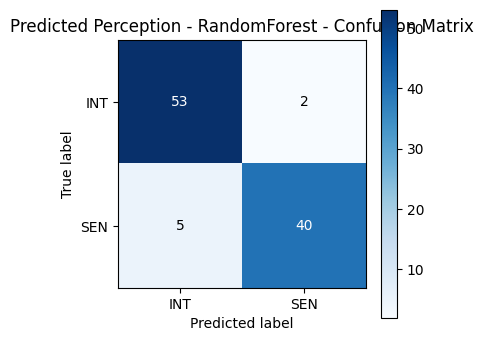

AUC Score: 0.971919191919192


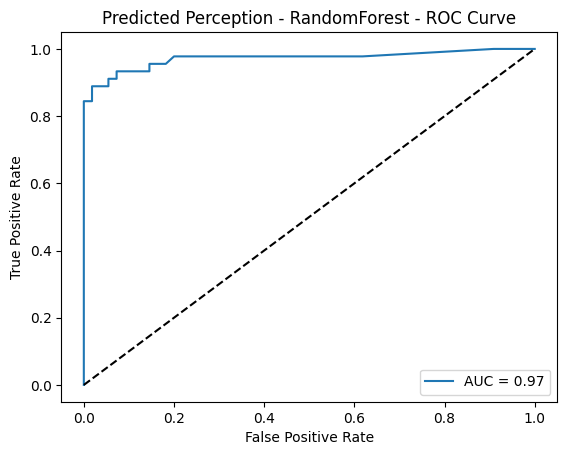


📌 Model: XGBoost
Accuracy: 0.94
Precision: 0.9424142207523769
Recall: 0.94
Specificity: 0.9818181818181818
F1 Score: 0.939657282741738
Cohen Kappa: 0.8778004073319756
Log Loss: 0.2004169961145047
Train Time (s): 0.46551036834716797
Test Time (s): 0.0010600090026855469
Confusion Matrix:
 [[54  1]
 [ 5 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95        55
           1       0.98      0.89      0.93        45

    accuracy                           0.94       100
   macro avg       0.95      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



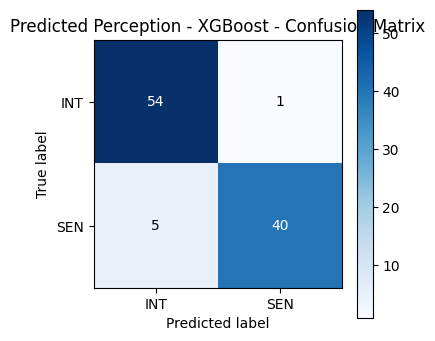

AUC Score: 0.9660606060606061


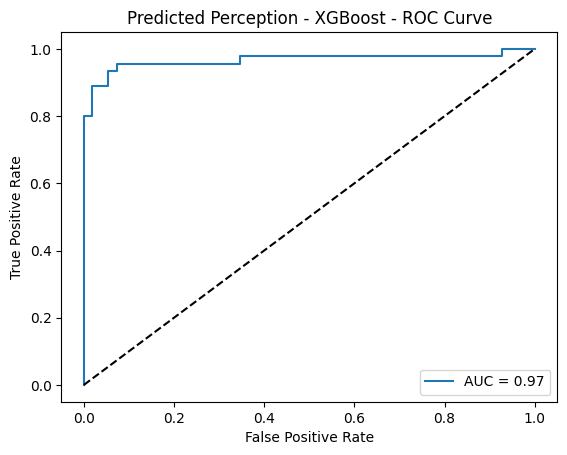


📌 Model: AdaBoost
Accuracy: 0.89
Precision: 0.8964770797962649
Recall: 0.89
Specificity: 0.9636363636363636
F1 Score: 0.8886520440737309
Cohen Kappa: 0.7745901639344263
Log Loss: 0.5295670353791582
Train Time (s): 0.20418667793273926
Test Time (s): 0.016007661819458008
Confusion Matrix:
 [[53  2]
 [ 9 36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.96      0.91        55
           1       0.95      0.80      0.87        45

    accuracy                           0.89       100
   macro avg       0.90      0.88      0.89       100
weighted avg       0.90      0.89      0.89       100



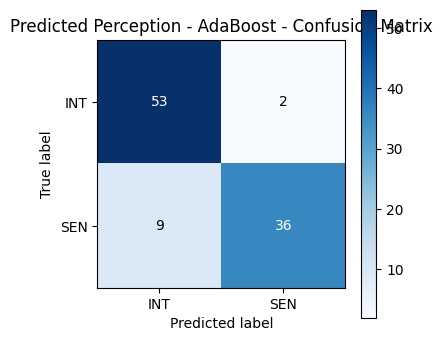

AUC Score: 0.9771717171717171


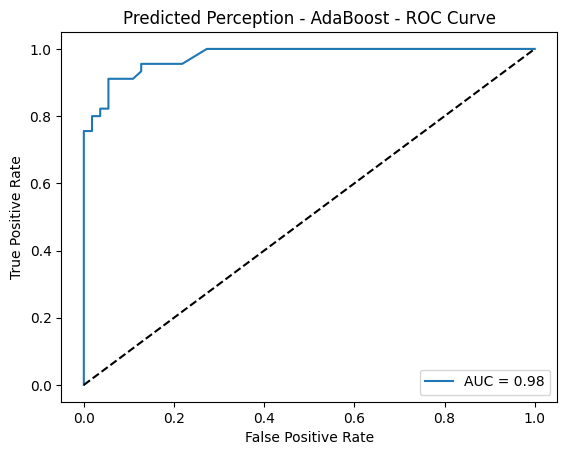


📌 Model: Bagging
Accuracy: 0.89
Precision: 0.8929166666666667
Recall: 0.89
Specificity: 0.9454545454545454
F1 Score: 0.889156010230179
Cohen Kappa: 0.7755102040816326
Log Loss: 0.9184228772784193
Train Time (s): 0.05443096160888672
Test Time (s): 0.002599000930786133
Confusion Matrix:
 [[52  3]
 [ 8 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.90        55
           1       0.93      0.82      0.87        45

    accuracy                           0.89       100
   macro avg       0.90      0.88      0.89       100
weighted avg       0.89      0.89      0.89       100



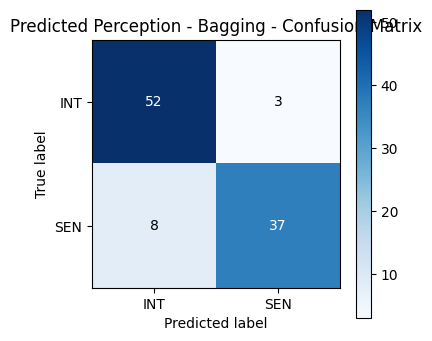

AUC Score: 0.9498989898989899


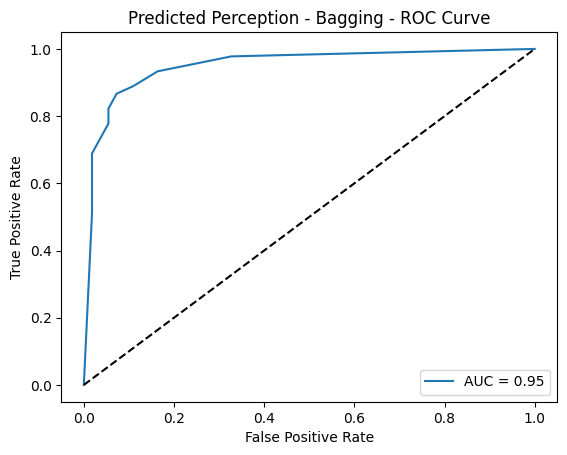


📌 Model: ExtraTrees
Accuracy: 0.94
Precision: 0.9424142207523769
Recall: 0.94
Specificity: 0.9818181818181818
F1 Score: 0.939657282741738
Cohen Kappa: 0.8778004073319756
Log Loss: 0.1772380252434572
Train Time (s): 0.17311882972717285
Test Time (s): 0.006942272186279297
Confusion Matrix:
 [[54  1]
 [ 5 40]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95        55
           1       0.98      0.89      0.93        45

    accuracy                           0.94       100
   macro avg       0.95      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



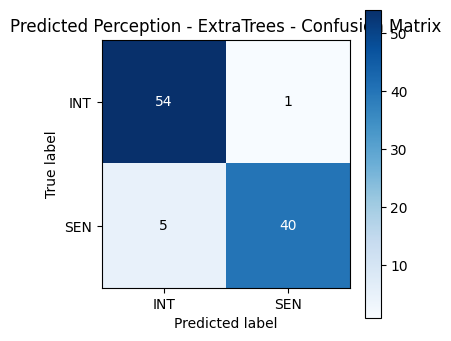

AUC Score: 0.9945454545454545


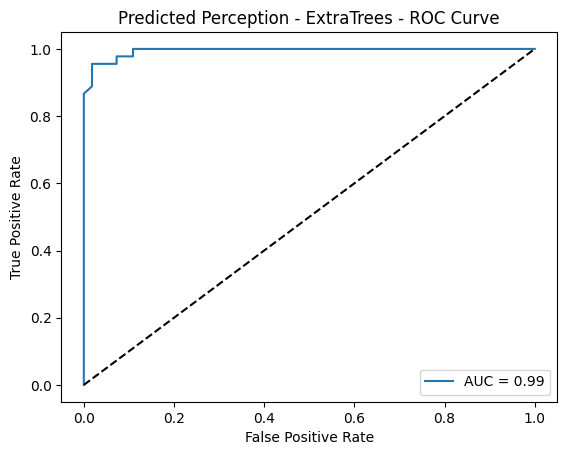


📌 Model: LogisticRegression
Accuracy: 0.77
Precision: 0.7696428571428572
Recall: 0.77
Specificity: 0.8
F1 Score: 0.7697439012045755
Cohen Kappa: 0.534412955465587
Log Loss: 0.487120611658876
Train Time (s): 0.021393299102783203
Test Time (s): 0.000270843505859375
Confusion Matrix:
 [[44 11]
 [12 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.80      0.79        55
           1       0.75      0.73      0.74        45

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



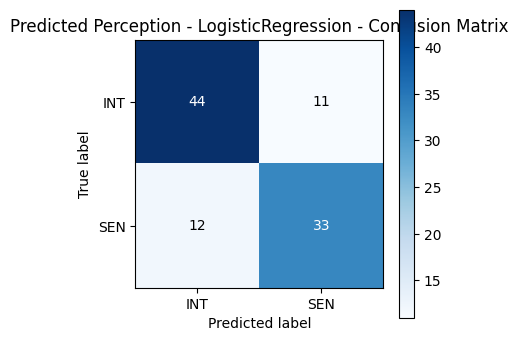

AUC Score: 0.846060606060606


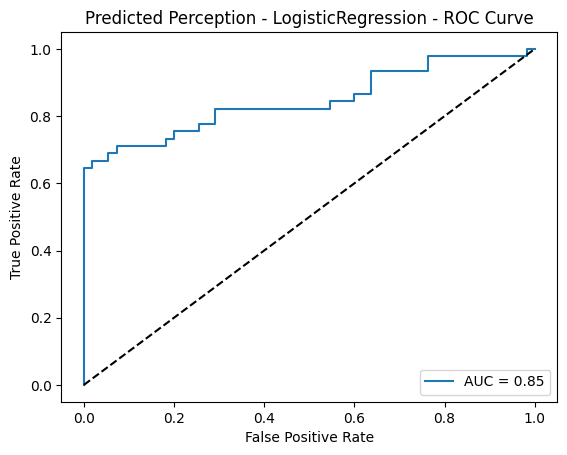


📌 Model: NaiveBayes
Accuracy: 0.86
Precision: 0.86
Recall: 0.86
Specificity: 0.8727272727272727
F1 Score: 0.86
Cohen Kappa: 0.7171717171717171
Log Loss: 0.5992275054772842
Train Time (s): 0.0015912055969238281
Test Time (s): 0.0003654956817626953
Confusion Matrix:
 [[48  7]
 [ 7 38]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87        55
           1       0.84      0.84      0.84        45

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100



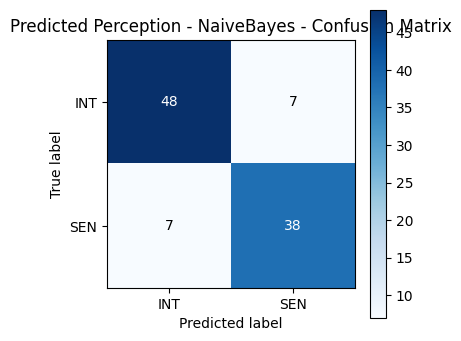

AUC Score: 0.8763636363636363


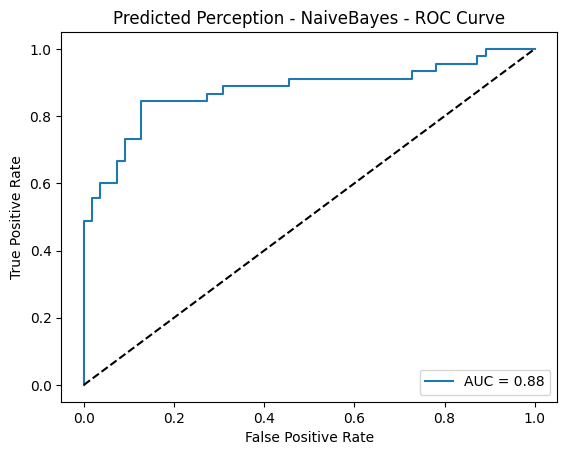


📌 Model: SVM
Accuracy: 0.9
Precision: 0.9092664092664093
Recall: 0.9
Specificity: 0.9818181818181818
F1 Score: 0.8985117817279868
Cohen Kappa: 0.7946611909650925
Log Loss: 0.2684579861884797
Train Time (s): 0.029668331146240234
Test Time (s): 0.0012059211730957031
Confusion Matrix:
 [[54  1]
 [ 9 36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92        55
           1       0.97      0.80      0.88        45

    accuracy                           0.90       100
   macro avg       0.92      0.89      0.90       100
weighted avg       0.91      0.90      0.90       100



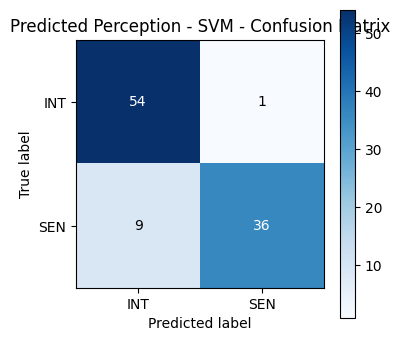

AUC Score: 0.9381818181818181


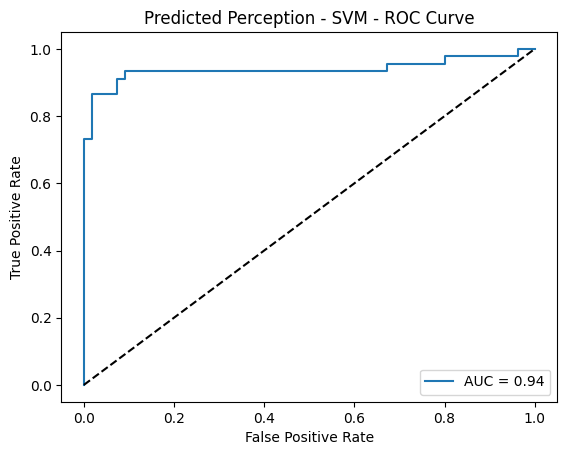


📌 Model: KNN
Accuracy: 0.87
Precision: 0.886764705882353
Recall: 0.87
Specificity: 0.9818181818181818
F1 Score: 0.8668584579976986
Cohen Kappa: 0.731404958677686
Log Loss: 1.9423127641743694
Train Time (s): 0.001256704330444336
Test Time (s): 0.009910106658935547
Confusion Matrix:
 [[54  1]
 [12 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.98      0.89        55
           1       0.97      0.73      0.84        45

    accuracy                           0.87       100
   macro avg       0.89      0.86      0.86       100
weighted avg       0.89      0.87      0.87       100



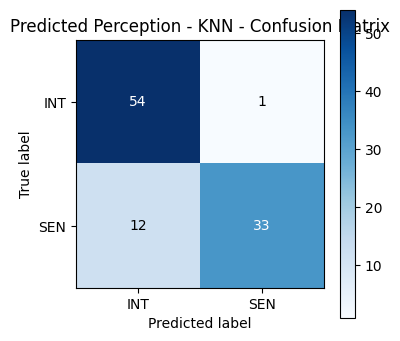

AUC Score: 0.930909090909091


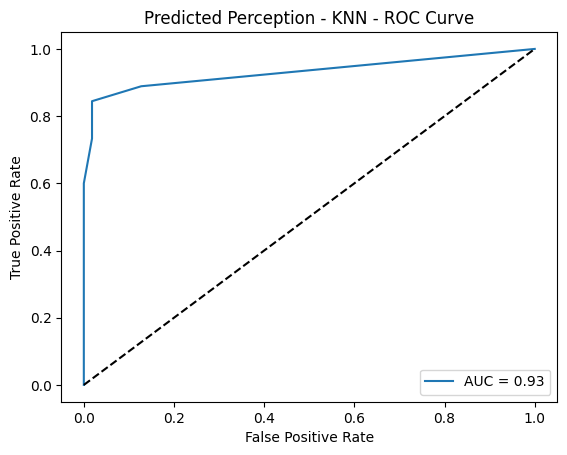


📌 Model: DecisionTree
Accuracy: 0.89
Precision: 0.8907635467980296
Recall: 0.89
Specificity: 0.9272727272727272
F1 Score: 0.8895636252670124
Cohen Kappa: 0.7764227642276422
Log Loss: 3.9648018728028864
Train Time (s): 0.004685163497924805
Test Time (s): 0.0003199577331542969
Confusion Matrix:
 [[51  4]
 [ 7 38]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.93      0.90        55
           1       0.90      0.84      0.87        45

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100



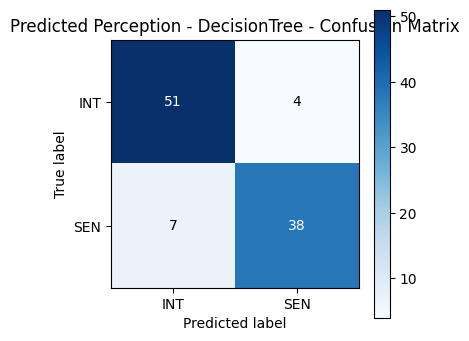

AUC Score: 0.8858585858585859


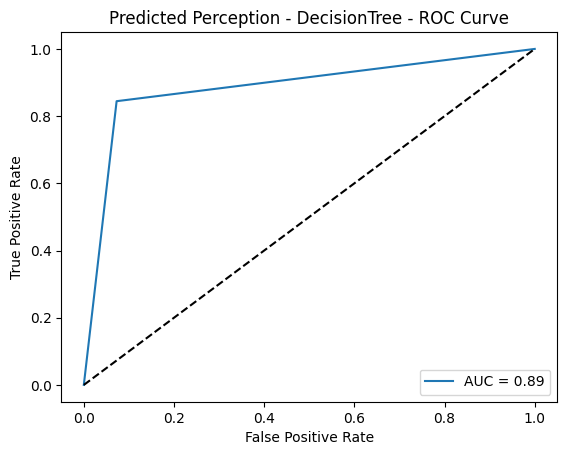


 FILE: Unlabelled_with_Predicted_LabelsInput.csv | TARGET: Predicted Input
✅ SMOTE Applied (k_neighbors=3) → Class Distribution: [311 311]

📌 Model: RandomForest
Accuracy: 0.992
Precision: 0.9921428571428571
Recall: 0.992
Specificity: 0.9857142857142858
F1 Score: 0.9920072590576188
Cohen Kappa: 0.9837977965003241
Log Loss: 0.011271896631983554
Train Time (s): 0.15454483032226562
Test Time (s): 0.0057566165924072266
Confusion Matrix:
 [[69  1]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.98      1.00      0.99        55

    accuracy                           0.99       125
   macro avg       0.99      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125



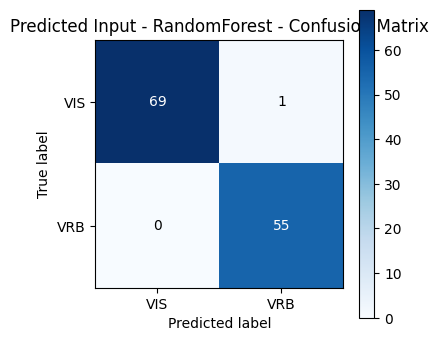

AUC Score: 1.0


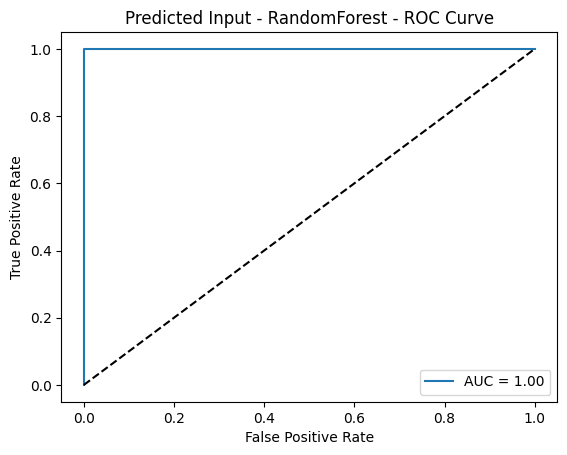


📌 Model: XGBoost
Accuracy: 0.992
Precision: 0.9921428571428571
Recall: 0.992
Specificity: 0.9857142857142858
F1 Score: 0.9920072590576188
Cohen Kappa: 0.9837977965003241
Log Loss: 0.08608599375668868
Train Time (s): 0.13724637031555176
Test Time (s): 0.0005586147308349609
Confusion Matrix:
 [[69  1]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.98      1.00      0.99        55

    accuracy                           0.99       125
   macro avg       0.99      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125



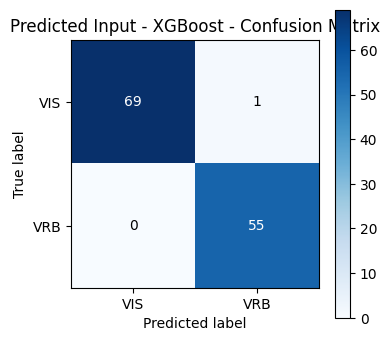

AUC Score: 0.9928571428571429


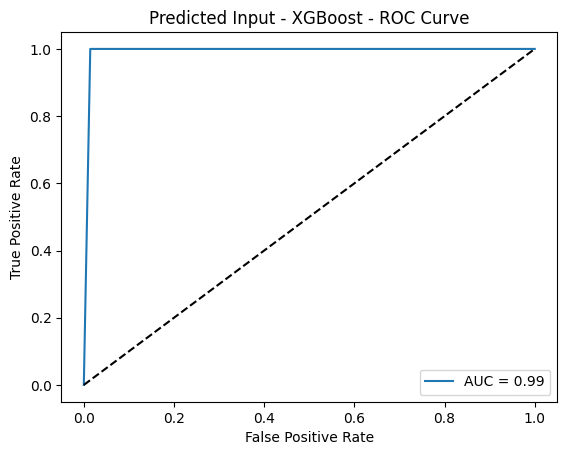


📌 Model: AdaBoost
Accuracy: 0.992
Precision: 0.9921428571428571
Recall: 0.992
Specificity: 0.9857142857142858
F1 Score: 0.9920072590576188
Cohen Kappa: 0.9837977965003241
Log Loss: 0.14292801104297273
Train Time (s): 0.00341796875
Test Time (s): 0.0006356239318847656
Confusion Matrix:
 [[69  1]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.98      1.00      0.99        55

    accuracy                           0.99       125
   macro avg       0.99      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125



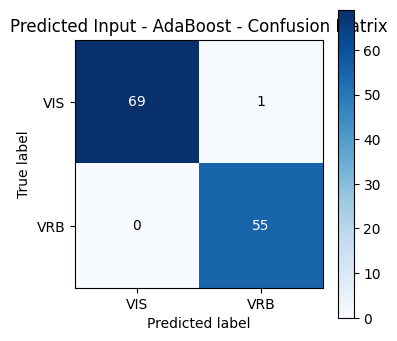

AUC Score: 0.9928571428571429


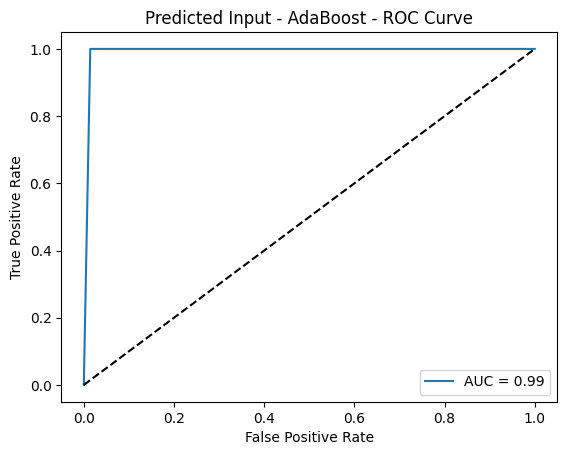


📌 Model: Bagging
Accuracy: 0.992
Precision: 0.9921428571428571
Recall: 0.992
Specificity: 0.9857142857142858
F1 Score: 0.9920072590576188
Cohen Kappa: 0.9837977965003241
Log Loss: 0.2883492271129374
Train Time (s): 0.030396223068237305
Test Time (s): 0.0018401145935058594
Confusion Matrix:
 [[69  1]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.98      1.00      0.99        55

    accuracy                           0.99       125
   macro avg       0.99      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125



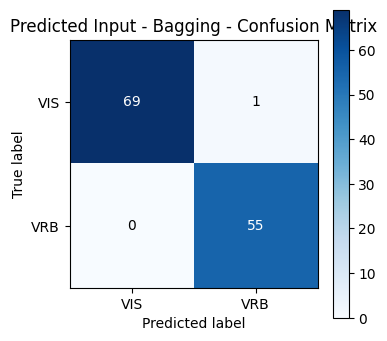

AUC Score: 0.9928571428571429


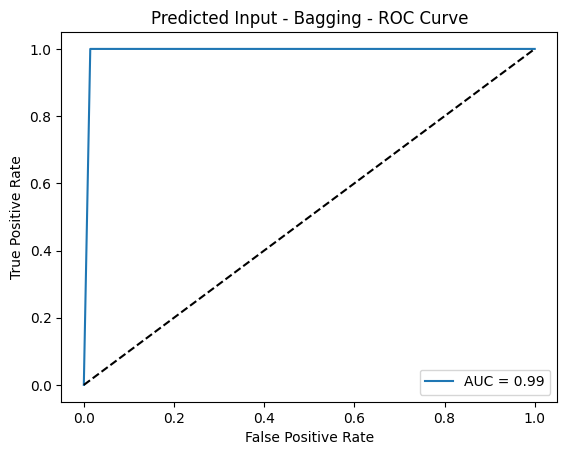


📌 Model: ExtraTrees
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
F1 Score: 1.0
Cohen Kappa: 1.0
Log Loss: 0.008567158766377975
Train Time (s): 0.1173548698425293
Test Time (s): 0.005939960479736328
Confusion Matrix:
 [[70  0]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        55

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



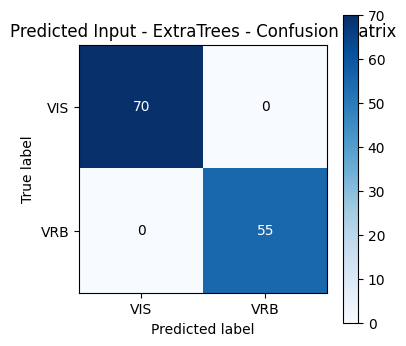

AUC Score: 1.0


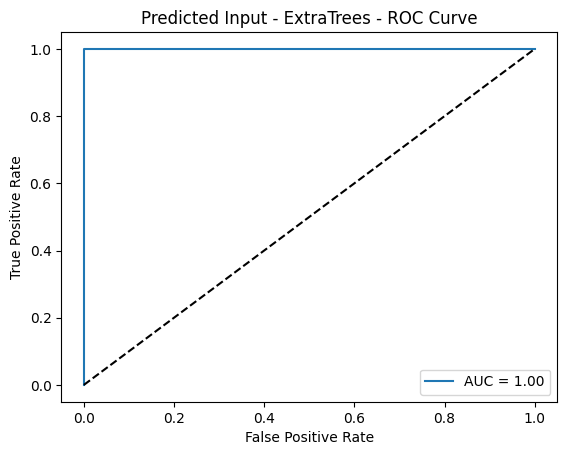


📌 Model: LogisticRegression
Accuracy: 0.992
Precision: 0.9921428571428571
Recall: 0.992
Specificity: 0.9857142857142858
F1 Score: 0.9920072590576188
Cohen Kappa: 0.9837977965003241
Log Loss: 0.011817557123967927
Train Time (s): 0.011612892150878906
Test Time (s): 0.0002713203430175781
Confusion Matrix:
 [[69  1]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.98      1.00      0.99        55

    accuracy                           0.99       125
   macro avg       0.99      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125



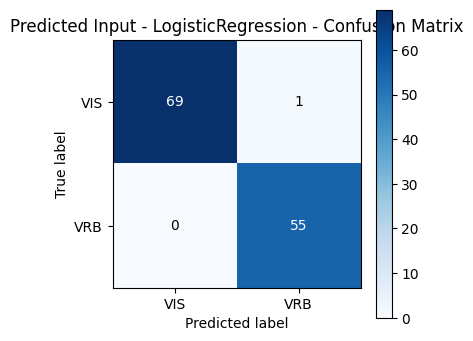

AUC Score: 1.0


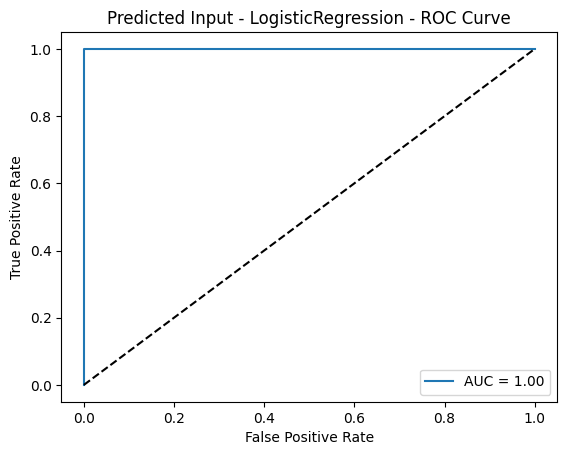


📌 Model: NaiveBayes
Accuracy: 0.992
Precision: 0.9921428571428571
Recall: 0.992
Specificity: 0.9857142857142858
F1 Score: 0.9920072590576188
Cohen Kappa: 0.9837977965003241
Log Loss: 0.1609490276141595
Train Time (s): 0.0016057491302490234
Test Time (s): 0.0003514289855957031
Confusion Matrix:
 [[69  1]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.98      1.00      0.99        55

    accuracy                           0.99       125
   macro avg       0.99      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125



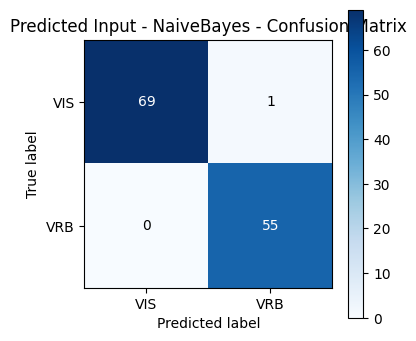

AUC Score: 1.0


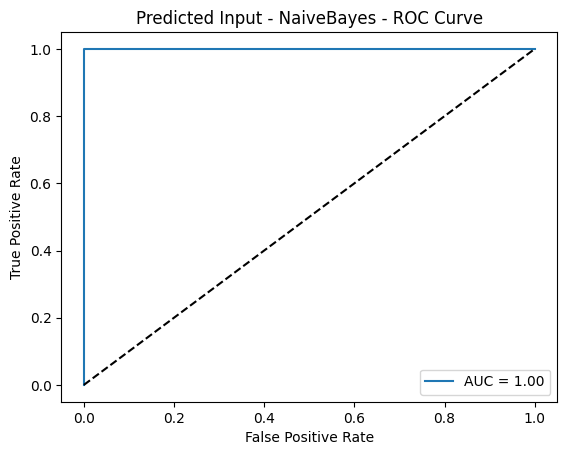


📌 Model: SVM
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
F1 Score: 1.0
Cohen Kappa: 1.0
Log Loss: 0.005705814857382558
Train Time (s): 0.006562471389770508
Test Time (s): 0.0007779598236083984
Confusion Matrix:
 [[70  0]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        55

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



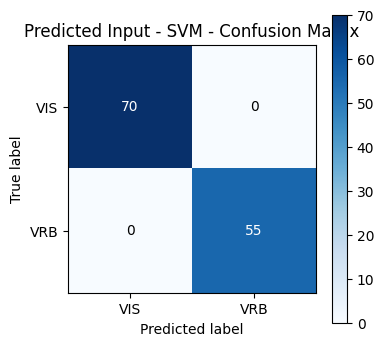

AUC Score: 1.0


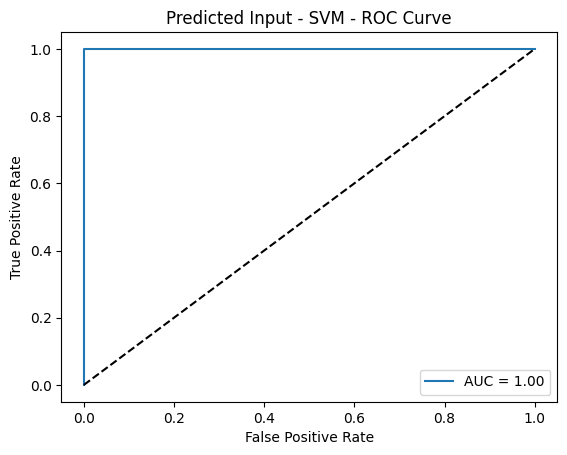


📌 Model: KNN
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Specificity: 1.0
F1 Score: 1.0
Cohen Kappa: 1.0
Log Loss: 0.004086604990128146
Train Time (s): 0.0017871856689453125
Test Time (s): 0.011536359786987305
Confusion Matrix:
 [[70  0]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        70
           1       1.00      1.00      1.00        55

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



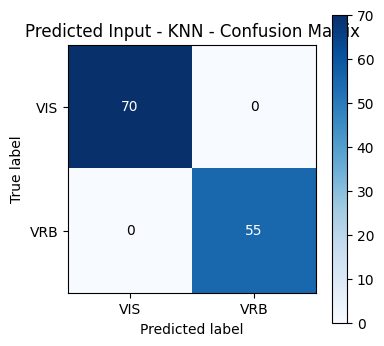

AUC Score: 1.0


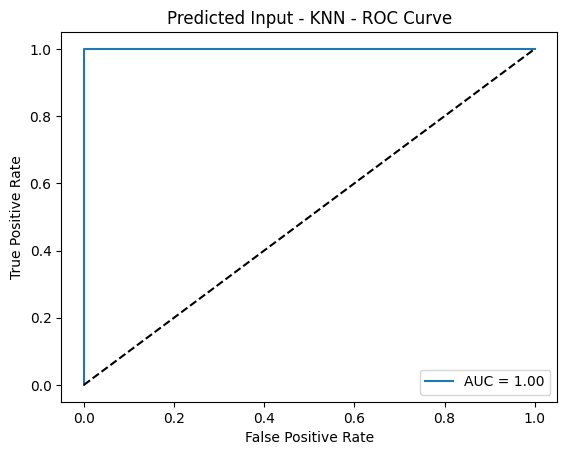


📌 Model: DecisionTree
Accuracy: 0.992
Precision: 0.9921428571428571
Recall: 0.992
Specificity: 0.9857142857142858
F1 Score: 0.9920072590576188
Cohen Kappa: 0.9837977965003241
Log Loss: 0.2883492271129374
Train Time (s): 0.002159595489501953
Test Time (s): 0.0003116130828857422
Confusion Matrix:
 [[69  1]
 [ 0 55]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        70
           1       0.98      1.00      0.99        55

    accuracy                           0.99       125
   macro avg       0.99      0.99      0.99       125
weighted avg       0.99      0.99      0.99       125



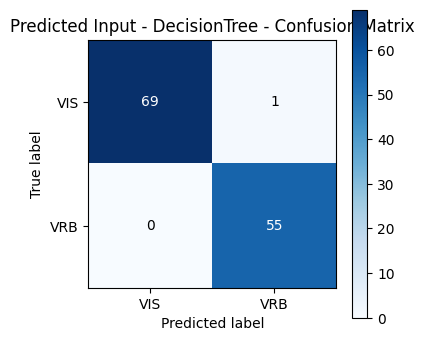

AUC Score: 0.9928571428571429


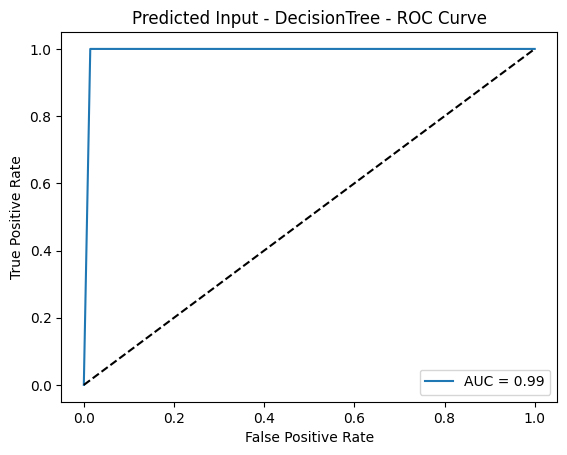

In [16]:
# ✅ Install libraries
!pip install imbalanced-learn
!pip install scikit-learn matplotlib

# ✅ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score, roc_auc_score, roc_curve, classification_report, cohen_kappa_score, log_loss
from imblearn.over_sampling import SMOTE

# ✅ Define Files and Targets
files_targets = {
    "Unlabelled_with_Predicted_LabelsProcessing.csv": "Predicted Processing",
    "Unlabelled_with_Predicted_LabelsPerception.csv": "Predicted Perception",
    "Unlabelled_with_Predicted_LabelsInput.csv": "Predicted Input"
}

input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# ✅ Loop through each target
for file, target_column in files_targets.items():
    print("\n=============================")
    print(" FILE:", file, "| TARGET:", target_column)
    print("=============================")

    # Load dataset
    df = pd.read_csv("/content/" + file)

    # Prepare X and y
    X = df[input_cols]
    y = df[target_column]

    # Encode target
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Scale input
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ✅ Auto adjust SMOTE k_neighbors
    counter = Counter(y_encoded)
    min_samples = min(counter.values())

    if min_samples < 2:
        print("❗ Too few samples for SMOTE. Skipping balancing.")
        X_balanced, y_balanced = X_scaled, y_encoded
    else:
        k_neighbors = min(5, min_samples - 1)
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_balanced, y_balanced = smote.fit_resample(X_scaled, y_encoded)
        print(f"✅ SMOTE Applied (k_neighbors={k_neighbors}) → Class Distribution:", np.bincount(y_balanced))

    # Split train-test
    X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

    # Define models
    models = {
        "RandomForest": RandomForestClassifier(),
        "XGBoost": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Bagging": BaggingClassifier(),
        "ExtraTrees": ExtraTreesClassifier(),
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "NaiveBayes": GaussianNB(),
        "SVM": SVC(probability=True),
        "KNN": KNeighborsClassifier(),
        "DecisionTree": DecisionTreeClassifier()
    }

    # Train and evaluate
    for name, model in models.items():
        start_train = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start_train

        start_test = time.time()
        y_pred = model.predict(X_test)
        test_time = time.time() - start_test

        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        precision = precision_score(y_test, y_pred, average="weighted")
        recall = recall_score(y_test, y_pred, average="weighted")
        cm = confusion_matrix(y_test, y_pred)
        specificity = cm[0][0] / (cm[0][0] + cm[0][1]) if (cm.shape[0] > 1 and (cm[0][0] + cm[0][1]) != 0) else 0
        kappa = cohen_kappa_score(y_test, y_pred)
        logloss = log_loss(y_test, model.predict_proba(X_test)) if hasattr(model, "predict_proba") else "N/A"

        # Print Results
        print("\n📌 Model:", name)
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("Specificity:", specificity)
        print("F1 Score:", f1)
        print("Cohen Kappa:", kappa)
        print("Log Loss:", logloss)
        print("Train Time (s):", train_time)
        print("Test Time (s):", test_time)
        print("Confusion Matrix:\n", cm)

        print("\nClassification Report:\n", classification_report(y_test, y_pred))

        # Plot Confusion Matrix
        plt.figure(figsize=(4, 4))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f"{target_column} - {name} - Confusion Matrix")
        plt.colorbar()
        plt.xticks(np.arange(len(le.classes_)), le.classes_)
        plt.yticks(np.arange(len(le.classes_)), le.classes_)
        plt.xlabel('Predicted label')
        plt.ylabel('True label')

        thresh = cm.max() / 2
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], 'd'),
                         ha="center", va="center",
                         color="white" if cm[i, j] > thresh else "black")

        plt.show()

        # Plot ROC Curve if binary classification
        if y_proba is not None and len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba)
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            print("AUC Score:", auc)

            plt.figure()
            plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
            plt.plot([0, 1], [0, 1], 'k--')
            plt.title(f"{target_column} - {name} - ROC Curve")
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.legend(loc='lower right')
            plt.show()


In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.impute import SimpleImputer

# Load the balanced Processing dataset
file_path = "Unlabelled_with_Predicted_LabelsProcessing.csv"
df = pd.read_csv(file_path)

# Clean columns
df.columns = df.columns.str.strip()

# Define input columns
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# Select X and y
X = df[input_cols]
y = df["Predicted Processing"]

# Encode y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  #  0= ACT,  1=REF

# Impute missing
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ==== CHI-SQUARE ====
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_imputed, y_encoded)

chi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'Chi2 Score': chi_selector.scores_,
    'p-value': chi_selector.pvalues_
}).sort_values(by='Chi2 Score', ascending=False)

print("\n=== Chi2 Feature Importance ===")
print(chi_df)

# ==== MUTUAL INFORMATION ====
mi_scores = mutual_info_classif(X_imputed, y_encoded)

mi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("\n=== Mutual Information Feature Importance ===")
print(mi_df)

# ==== 0 vs 1 mean compare ====
X_act = X_imputed[y_encoded == 0]
X_ref = X_imputed[y_encoded == 1]

feature_direction = []
for feature in X_imputed.columns:
    if X_act[feature].mean() > X_ref[feature].mean():
        feature_direction.append("ACT")
    else:
        feature_direction.append("REF")

direction_df = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Higher In": feature_direction
})

print("\n=== Feature Higher in ACT or REF ===")
print(direction_df)

# Final Combine Report
final_df = chi_df.merge(mi_df, on="Feature").merge(direction_df, on="Feature")
print("\n FINAL FEATURE ENGINEERING REPORT:")
print(final_df)

# Optional → Save to Excel
final_df.to_excel("Processing_Feature_Engineering_Report.xlsx", index=False)
print("\nSaved Final Report → Processing_Feature_Engineering_Report.xlsx")


# Create lists to hold features for ACT and REF
act_features = direction_df[direction_df["Higher In"] == "ACT"]["Feature"].tolist()
ref_features = direction_df[direction_df["Higher In"] == "REF"]["Feature"].tolist()

# Print them nicely
print("\n Features more associated with ACT:")
print(act_features)

print("\n Features more associated with REF:")
print(ref_features)




=== Chi2 Feature Importance ===
               Feature  Chi2 Score       p-value
9               paused  377.260427  4.913772e-84
4     Visual Materials  211.912977  5.254328e-48
1         Reading file  165.006045  9.119885e-38
2   Abstract materiale  111.434152  4.753339e-26
8              playing   94.954641  1.947980e-22
11           buffering   85.495328  2.322498e-20
10           unstarted   44.908633  2.064457e-11
3    Concrete material   43.268135  4.772935e-11
0      Course overview   36.389184  1.615975e-09
5      Self-assessment   22.842097  1.758710e-06
7       Quiz submitted    0.584465  4.445676e-01
6     Exercises submit    0.010096  9.199648e-01

=== Mutual Information Feature Importance ===
               Feature  MI Score
10           unstarted  0.149189
8              playing  0.089540
11           buffering  0.089255
1         Reading file  0.074003
9               paused  0.066668
7       Quiz submitted  0.061703
3    Concrete material  0.036401
5      Self-assessm

In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.impute import SimpleImputer

# Load the balanced Input dataset
file_path = "Unlabelled_with_Predicted_LabelsInput.csv"
df = pd.read_csv(file_path)

# Clean columns
df.columns = df.columns.str.strip()

# Define input columns
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# Select X and y
X = df[input_cols]
y = df["Predicted Input"]

# Encode y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 0 =VIS, 1=VRB

# Impute missing
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ==== CHI-SQUARE ====
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_imputed, y_encoded)

chi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'Chi2 Score': chi_selector.scores_,
    'p-value': chi_selector.pvalues_
}).sort_values(by='Chi2 Score', ascending=False)

print("\n=== Chi2 Feature Importance ===")
print(chi_df)

# ==== MUTUAL INFORMATION ====
mi_scores = mutual_info_classif(X_imputed, y_encoded)

mi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("\n=== Mutual Information Feature Importance ===")
print(mi_df)

# ==== 0 vs 1 mean compare ====
X_act = X_imputed[y_encoded == 0]
X_ref = X_imputed[y_encoded == 1]

feature_direction = []
for feature in X_imputed.columns:
    if X_act[feature].mean() > X_ref[feature].mean():
        feature_direction.append("VIS")
    else:
        feature_direction.append("VRB")

direction_df = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Higher In": feature_direction
})

print("\n=== Feature Higher in VIS or VRB ===")
print(direction_df)

# Final Combine Report
final_df = chi_df.merge(mi_df, on="Feature").merge(direction_df, on="Feature")
print("\n FINAL FEATURE ENGINEERING REPORT:")
print(final_df)
# Create lists to hold features for VIS and VRB
act_features = direction_df[direction_df["Higher In"] == "VIS"]["Feature"].tolist()
ref_features = direction_df[direction_df["Higher In"] == "VRB"]["Feature"].tolist()

# Print them nicely
print("\n Features more associated with VIS:")
print(act_features)

print("\n Features more associated with VRB:")
print(ref_features)

# Optional → Save to Excel
final_df.to_excel("Input_Feature_Engineering_Report.xlsx", index=False)
print("\nSaved Final Report → Input_Feature_Engineering_Report.xlsx")


=== Chi2 Feature Importance ===
               Feature   Chi2 Score        p-value
1         Reading file  2883.715843   0.000000e+00
2   Abstract materiale  1642.187550   0.000000e+00
3    Concrete material  1576.406235   0.000000e+00
5      Self-assessment   528.004313  7.675785e-117
4     Visual Materials   386.887884   3.939087e-86
0      Course overview    24.317561   8.169092e-07
10           unstarted     8.338886   3.880539e-03
8              playing     2.442385   1.180965e-01
11           buffering     2.076654   1.495677e-01
9               paused     0.644014   4.222611e-01
6     Exercises submit     0.310834   5.771687e-01
7       Quiz submitted     0.003877   9.503538e-01

=== Mutual Information Feature Importance ===
               Feature  MI Score
6     Exercises submit  0.081356
2   Abstract materiale  0.059791
1         Reading file  0.034179
5      Self-assessment  0.024240
3    Concrete material  0.005960
8              playing  0.003936
10           unstarted  0.

In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.impute import SimpleImputer

# Load the balanced Perception dataset
file_path = "Unlabelled_with_Predicted_LabelsPerception.csv"
df = pd.read_csv(file_path)

# Clean columns
df.columns = df.columns.str.strip()

# Define input columns
input_cols = ["Course overview", "Reading file", "Abstract materiale", "Concrete material",
              "Visual Materials", "Self-assessment", "Exercises submit", "Quiz submitted",
              "playing", "paused", "unstarted", "buffering"]

# Select X and y
X = df[input_cols]
y = df["Predicted Perception"]

# Encode y
le = LabelEncoder()
y_encoded = le.fit_transform(y)  #  0= SEN,  1=INT

# Impute missing
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ==== CHI-SQUARE ====
chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(X_imputed, y_encoded)

chi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'Chi2 Score': chi_selector.scores_,
    'p-value': chi_selector.pvalues_
}).sort_values(by='Chi2 Score', ascending=False)

print("\n=== Chi2 Feature Importance ===")
print(chi_df)

# ==== MUTUAL INFORMATION ====
mi_scores = mutual_info_classif(X_imputed, y_encoded)

mi_df = pd.DataFrame({
    'Feature': X_imputed.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("\n=== Mutual Information Feature Importance ===")
print(mi_df)

# ==== 0 vs 1 mean compare ====
X_act = X_imputed[y_encoded == 0]
X_ref = X_imputed[y_encoded == 1]

feature_direction = []
for feature in X_imputed.columns:
    if X_act[feature].mean() > X_ref[feature].mean():
        feature_direction.append("SEN")
    else:
        feature_direction.append("INT")

direction_df = pd.DataFrame({
    "Feature": X_imputed.columns,
    "Higher In": feature_direction
})

print("\n=== Feature Higher in SEN or INT ===")
print(direction_df)

# Final Combine Report
final_df = chi_df.merge(mi_df, on="Feature").merge(direction_df, on="Feature")
print("\n FINAL FEATURE ENGINEERING REPORT:")
print(final_df)

# Create lists to hold features for ACT and REF
act_features = direction_df[direction_df["Higher In"] == "SEN"]["Feature"].tolist()
ref_features = direction_df[direction_df["Higher In"] == "INT"]["Feature"].tolist()

# Print them nicely
print("\n Features more associated with SEN:")
print(act_features)

print("\n Features more associated with INT:")
print(ref_features)


# Optional → Save to Excel
final_df.to_excel("Perception_Feature_Engineering_Report.xlsx", index=False)
print("\nSaved Final Report → Perception_Feature_Engineering_Report.xlsx")


=== Chi2 Feature Importance ===
               Feature   Chi2 Score        p-value
1         Reading file  1571.196677   0.000000e+00
3    Concrete material  1070.696374  7.725716e-235
2   Abstract materiale   999.484557  2.324366e-219
4     Visual Materials   857.739225  1.510259e-188
9               paused   406.662048   1.953080e-90
5      Self-assessment   390.180452   7.561236e-87
10           unstarted    62.542226   2.607927e-15
0      Course overview    61.628811   4.147059e-15
8              playing    40.870097   1.626916e-10
11           buffering     3.500534   6.134905e-02
7       Quiz submitted     1.410769   2.349287e-01
6     Exercises submit     0.560187   4.541850e-01

=== Mutual Information Feature Importance ===
               Feature  MI Score
1         Reading file  0.145381
5      Self-assessment  0.135505
2   Abstract materiale  0.132573
3    Concrete material  0.126036
4     Visual Materials  0.090762
10           unstarted  0.077207
9               paused  0.